## In Class Activity April 21st

In [ ]:
# pip install category_encoders

### Libraries, data import & EDA

In [2]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import boxcox
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import sweetviz as sv
from sklearn.cluster import KMeans
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [3]:
# importing the data
adult = pd.read_csv("adult.csv")
adult.head()
 

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# quick eda with sweetviz
report = sv.analyze(adult)
report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Model agnostic data preprocessing & train/test split for reuse in all cells

In [5]:
# replace ? with np.nan
adult = adult.replace("?", np.nan)
adult.head()

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# convert gender to 0/1 (doesn't need categorical encoding since it's binary)
if "gender" in adult.columns:
    adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)  
    
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,0,0,0,30,United-States,0


In [6]:
# fixed train/test split for the entire notebook

train_idx, test_idx = train_test_split(
    adult.index,
    test_size=0.2,
    stratify=adult["income"],
    random_state=42
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 39073
Test rows: 9769


### Preprocessing for models without native category handling

In [7]:
# one hot encoding low cardinality features for models that don't handle categorical variables natively

adult_ohe = adult.copy()

adult_ohe = pd.get_dummies(
    adult_ohe,
    columns=["marital-status", "relationship", "race", "workclass"],
    drop_first=True
)

# quick target encoding for screening only (this has data leakage--screening only, not for final model)
occupation_encoder = ce.TargetEncoder(cols=["occupation"])
adult_ohe["occupation_encoded"] = occupation_encoder.fit_transform(
    adult_ohe[["occupation"]], adult_ohe["income"]
)["occupation"]

native_country_encoder = ce.TargetEncoder(cols=["native-country"])
adult_ohe["native_country_encoded"] = native_country_encoder.fit_transform(
    adult_ohe[["native-country"]], adult_ohe["income"]
)["native-country"]

adult_ohe.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,race_White,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded
0,25,226802,11th,7,Machine-op-inspct,1,0,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
1,38,89814,HS-grad,9,Farming-fishing,1,0,0,50,United-States,...,True,False,False,True,False,False,False,False,0.116107,0.243977
2,28,336951,Assoc-acdm,12,Protective-serv,1,0,0,40,United-States,...,True,True,False,False,False,False,False,False,0.313327,0.243977
3,44,160323,Some-college,10,Machine-op-inspct,1,7688,0,40,United-States,...,False,False,False,True,False,False,False,False,0.123097,0.243977
4,18,103497,Some-college,10,NaN,0,0,0,30,United-States,...,True,False,False,False,False,False,False,False,0.094340,0.243977


### Feature-engine library 

In [8]:
# !pip install feature-engine

In [9]:
# OPTIONAL standalone example using feature-engine

from feature_engine.transformation import YeoJohnsonTransformer
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder

df_fe = adult.copy()

cat_cols = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = ["capital-gain", "capital-loss"]

# make missing categorical values explicit
df_fe[cat_cols] = df_fe[cat_cols].fillna("Unknown")

# transform skewed numeric features
yj = YeoJohnsonTransformer(variables=num_cols)
df_fe = yj.fit_transform(df_fe)

# group rare categories
rare = RareLabelEncoder(tol=0.01, variables=cat_cols)
df_fe = rare.fit_transform(df_fe)

# frequency encode categorical variables
freq = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
df_fe = freq.fit_transform(df_fe)

print("Example after feature-engine transformations + encoding:")
print(df_fe[num_cols + cat_cols[:3]].head())

c:\Users\tyler\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\tyler\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\tyler\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\tyler\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable race is less than that indicated in n_categories. Thu

Example after feature-engine transformations + encoding:
   capital-gain  capital-loss  workclass  education  marital-status
0      0.000000           0.0   0.694198   0.037099        0.329982
1      0.000000           0.0   0.694198   0.323164        0.458192
2      0.000000           0.0   0.064207   0.032779        0.458192
3      0.728649           0.0   0.694198   0.222718        0.458192
4      0.000000           0.0   0.057307   0.222718        0.329982


#### Baseline modeling with CV

In [10]:
# baseline models with CV
X = adult_ohe.drop(columns=["income", "occupation", "fnlwgt", "education", "native-country"])
y = adult_ohe["income"]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")
print(f"RF CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:\n", classification_report(y_test, rf_pred))

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="accuracy")
print(f"XGB CV Accuracy: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGB Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB Classification Report:\n", classification_report(y_test, xgb_pred))

RF CV Accuracy: 0.8453 ± 0.0042
RF Test Accuracy: 0.8482956290306071
RF Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      7431
           1       0.70      0.65      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.79      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769

XGB CV Accuracy: 0.8722 ± 0.0049
XGB Test Accuracy: 0.8757293479373528
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### Which features are important?

In [11]:
# feature importance from baseline models using one hot encoded features
rf_importance = rf.feature_importances_
xgb_importance = xgb.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
xgb_importance_df = pd.DataFrame({"feature": feature_names, "importance": xgb_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)
xgb_importance_df = xgb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 RF Features:\n", rf_importance_df.head(10))
print("Top 10 XGB Features:\n", xgb_importance_df.head(10))

Top 10 RF Features:
                               feature  importance
0                                 age    0.226183
7   marital-status_Married-civ-spouse    0.140399
1                     educational-num    0.110669
28                 occupation_encoded    0.109980
5                      hours-per-week    0.102165
3                        capital-gain    0.078969
9        marital-status_Never-married    0.048462
4                        capital-loss    0.027465
29             native_country_encoded    0.022775
12         relationship_Not-in-family    0.020687
Top 10 XGB Features:
                               feature  importance
7   marital-status_Married-civ-spouse    0.612760
3                        capital-gain    0.074798
1                     educational-num    0.049730
4                        capital-loss    0.028812
14             relationship_Own-child    0.027086
28                 occupation_encoded    0.026445
6    marital-status_Married-AF-spouse    0.014820
16     

### Where are the errors happening?

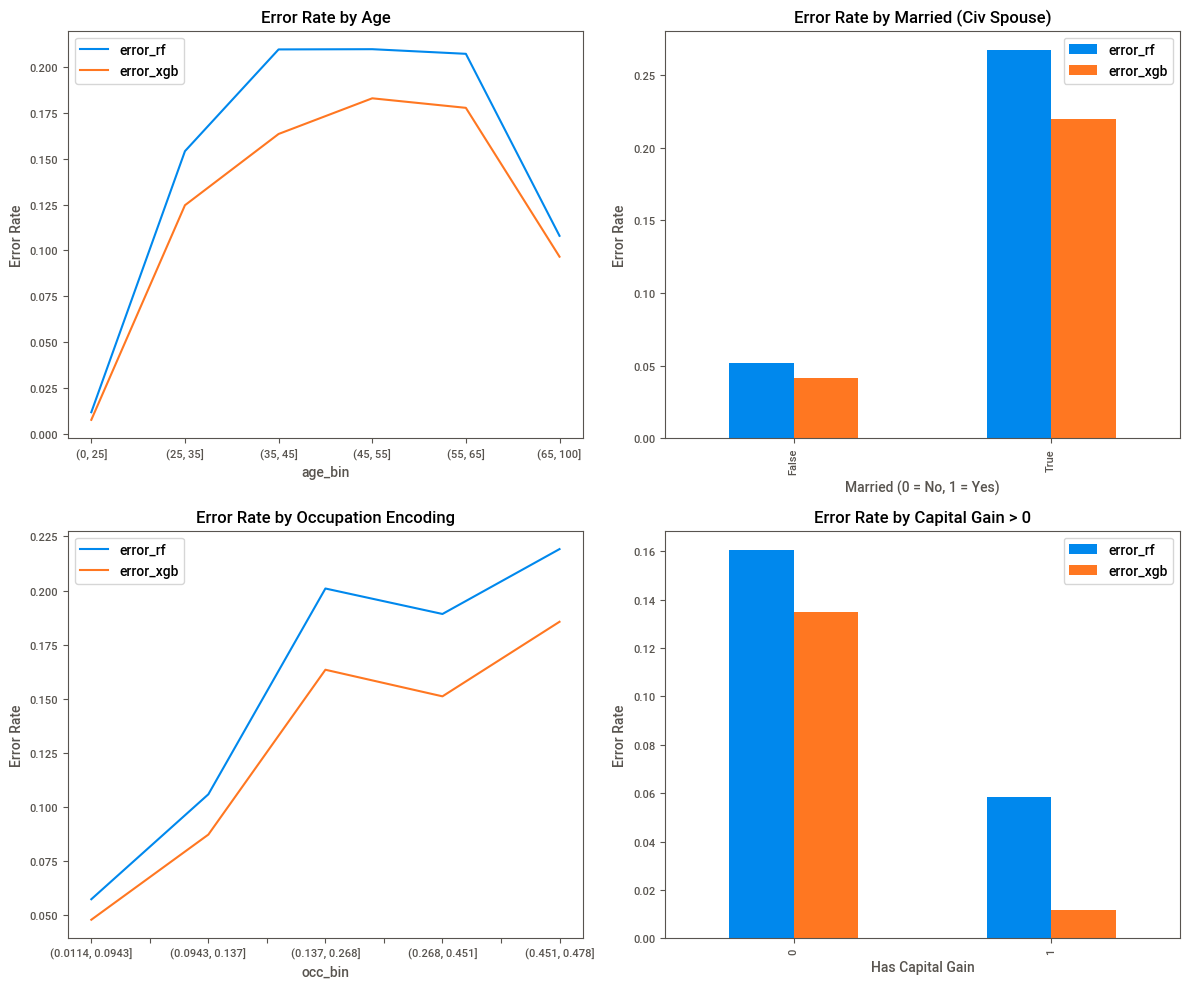

In [12]:
# build error dataframe
df_err = X_test.copy()
df_err["y_true"] = y_test
df_err["error_rf"] = (rf_pred != y_test).astype(int)
df_err["error_xgb"] = (xgb_pred != y_test).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. Error vs Age (binned) ---
df_err["age_bin"] = pd.cut(df_err["age"], bins=[0, 25, 35, 45, 55, 65, 100])
df_err.groupby("age_bin", observed=False)[["error_rf", "error_xgb"]].mean().plot(ax=axes[0,0])
axes[0,0].set_title("Error Rate by Age")
axes[0,0].set_ylabel("Error Rate")

# --- 2. Error vs Married ---
df_err.groupby("marital-status_Married-civ-spouse")[["error_rf", "error_xgb"]].mean().plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Error Rate by Married (Civ Spouse)")
axes[0,1].set_xlabel("Married (0 = No, 1 = Yes)")
axes[0,1].set_ylabel("Error Rate")

# --- 3. Error vs Occupation Encoded (binned) ---
df_err["occ_bin"] = pd.qcut(df_err["occupation_encoded"], q=5, duplicates="drop")
df_err.groupby("occ_bin", observed=False)[["error_rf", "error_xgb"]].mean().plot(ax=axes[1,0])
axes[1,0].set_title("Error Rate by Occupation Encoding")
axes[1,0].set_ylabel("Error Rate")

# --- 4. Error vs Capital Gain (binary) ---
df_err["has_gain"] = (df_err["capital-gain"] > 0).astype(int)
df_err.groupby("has_gain")[["error_rf", "error_xgb"]].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Error Rate by Capital Gain > 0")
axes[1,1].set_xlabel("Has Capital Gain")
axes[1,1].set_ylabel("Error Rate")

plt.tight_layout()
plt.show()

### OOF Target Encoding & New Interaction Features

In [13]:
# proper OOF target encoding: split first, OOF encode train, encode test from full train
from sklearn.model_selection import KFold

X_base = adult_ohe.drop(columns=["income"]).copy()
y_base = adult_ohe["income"].copy()

X_train_base = X_base.loc[train_idx].copy()
X_test_base = X_base.loc[test_idx].copy()
y_train_base = y_base.loc[train_idx].copy()
y_test_base = y_base.loc[test_idx].copy()

def add_oof_target_encoding(X_train, X_test, y_train, col, new_col, n_splits=5):
    X_train = X_train.copy()
    X_test = X_test.copy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train[new_col] = np.nan

    for tr_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        encoder = ce.TargetEncoder(cols=[col])
        encoder.fit(X_tr[[col]], y_tr)

        X_train.iloc[val_idx, X_train.columns.get_loc(new_col)] = (
            encoder.transform(X_val[[col]])[col].values
        )

    final_encoder = ce.TargetEncoder(cols=[col])
    final_encoder.fit(X_train[[col]], y_train)
    X_test[new_col] = final_encoder.transform(X_test[[col]])[col].values

    return X_train, X_test

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_base, X_test_base, y_train_base,
    col="occupation", new_col="occupation_oof"
)

X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_oof, X_test_oof, y_train_base,
    col="native-country", new_col="native_country_oof"
)

X_train_oof.head()

,age,fnlwgt,education,educational-num,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country,...,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,occupation_encoded,native_country_encoded,occupation_oof,native_country_oof
34342,71,77253,HS-grad,9,Handlers-cleaners,1,0,0,17,United-States,...,False,True,False,False,False,False,0.066602,0.243977,0.066375,0.243592
18559,17,329783,10th,6,Sales,0,0,0,10,United-States,...,False,True,False,False,False,False,0.267987,0.243977,0.265369,0.243269
12477,27,91257,HS-grad,9,Other-service,1,0,0,40,El-Salvador,...,False,True,False,False,False,False,0.041438,0.070968,0.039834,0.075380
560,43,125577,HS-grad,9,Adm-clerical,0,0,0,40,United-States,...,False,True,False,False,False,False,0.136874,0.243977,0.144047,0.243269
3427,31,137978,Bachelors,13,Exec-managerial,1,0,0,40,United-States,...,False,True,False,False,False,False,0.477818,0.243977,0.488712,0.244195


In [15]:
# engineering new feature based on error analysis insights
X_train_oof["married_occ_interaction"] = (
    X_train_oof["marital-status_Married-civ-spouse"] * X_train_oof["occupation_oof"]
)

X_test_oof["married_occ_interaction"] = (
    X_test_oof["marital-status_Married-civ-spouse"] * X_test_oof["occupation_oof"]
)

X_train_oof[["marital-status_Married-civ-spouse", "occupation_oof", "married_occ_interaction"]].head()

,marital-status_Married-civ-spouse,occupation_oof,married_occ_interaction
34342,False,0.066375,0.000000
18559,False,0.265369,0.000000
12477,True,0.039834,0.039834
560,False,0.144047,0.000000
3427,True,0.488712,0.488712


In [16]:
# modeling with new OOF and interaction features
drop_cols = ["occupation", "fnlwgt", "education", "native-country", 
             "occupation_encoded", "native_country_encoded"]

X_train = X_train_oof.drop(columns=drop_cols)
X_test = X_test_oof.drop(columns=drop_cols)
y_train = y_train_base
y_test = y_test_base

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")
print(f"RF CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:\n", classification_report(y_test, rf_pred))

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="accuracy")
print(f"XGB CV Accuracy: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGB Test Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGB Classification Report:\n", classification_report(y_test, xgb_pred))

RF CV Accuracy: 0.8495 ± 0.0034
RF Test Accuracy: 0.8607841130105436
RF Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      7431
           1       0.76      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769

XGB CV Accuracy: 0.8689 ± 0.0047
XGB Test Accuracy: 0.8751151602006346
XGB Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.65      0.71      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [17]:
# feature importance from random forest
rf_importance = rf.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)       
print("Top 10 RF Features:\n", rf_importance_df.head(10))   

# feature importance from xgboost
xgb_importance = xgb.feature_importances_
xgb_importance_df = pd.DataFrame({"feature": feature_names, "importance": xgb_importance})
xgb_importance_df = xgb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 XGB Features:\n", xgb_importance_df.head(10))

Top 10 RF Features:
                               feature  importance
0                                 age    0.190703
30            married_occ_interaction    0.161269
1                     educational-num    0.098779
5                      hours-per-week    0.089606
28                     occupation_oof    0.089253
7   marital-status_Married-civ-spouse    0.085017
3                        capital-gain    0.076185
29                 native_country_oof    0.047347
9        marital-status_Never-married    0.034092
4                        capital-loss    0.024281
Top 10 XGB Features:
                              feature  importance
30           married_occ_interaction    0.322888
3                       capital-gain    0.122055
1                    educational-num    0.075140
14            relationship_Own-child    0.065914
4                       capital-loss    0.053175
16                 relationship_Wife    0.025524
28                    occupation_oof    0.025512
0              

In [18]:
# building xgboost using native categorical feature handling

adult_cat = adult.copy()

for col in ["workclass", "education", "marital-status", "occupation", "relationship", "race", "native-country"]:
    adult_cat[col] = adult_cat[col].fillna("Unknown").astype("category")

X_cat = adult_cat.drop(columns=["income", "fnlwgt"])
y_cat = adult_cat["income"]

X_train_cat = X_cat.loc[train_idx]
X_test_cat = X_cat.loc[test_idx]
y_train_cat = y_cat.loc[train_idx]
y_test_cat = y_cat.loc[test_idx]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cat = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,
    tree_method="hist"
)

xgb_cat_cv_scores = cross_val_score(xgb_cat, X_train_cat, y_train_cat, cv=kf, scoring="accuracy")
print(f"XGB with Native Cat CV Accuracy: {xgb_cat_cv_scores.mean():.4f} ± {xgb_cat_cv_scores.std():.4f}")

xgb_cat.fit(X_train_cat, y_train_cat)
xgb_cat_pred = xgb_cat.predict(X_test_cat)

print("XGB with Native Cat Test Accuracy:", accuracy_score(y_test_cat, xgb_cat_pred))
print("XGB with Native Cat Classification Report:\n", classification_report(y_test_cat, xgb_cat_pred))

XGB with Native Cat CV Accuracy: 0.8703 ± 0.0046
XGB with Native Cat Test Accuracy: 0.8765482649196438
XGB with Native Cat Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



In [19]:
# feature importance from xgboost with native categorical handling
xgb_cat_importance = xgb_cat.feature_importances_
feature_names = X_train.columns
feature_names = X_train_cat.columns
xgb_cat_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_cat_importance
})
xgb_cat_importance_df = xgb_cat_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 XGB with Native Cat Features:\n", xgb_cat_importance_df.head(10)) 

Top 10 XGB with Native Cat Features:
            feature  importance
6     relationship    0.328320
4   marital-status    0.186007
9     capital-gain    0.149716
2        education    0.084638
10    capital-loss    0.071951
5       occupation    0.046599
0              age    0.028232
11  hours-per-week    0.022997
8           gender    0.022119
1        workclass    0.019755


### Stacking predictions-average

In [20]:
# building ensemble of RF and XGB with native categorical handling

# RF data from OOF / one-hot path
drop_cols = ["occupation", "fnlwgt", "education", "native-country", "occupation_encoded", "native_country_encoded"]

X_train_ohe = X_train_oof.drop(columns=drop_cols)
X_test_ohe = X_test_oof.drop(columns=drop_cols)

y_train = y_train_base
y_test = y_test_base

# native categorical data from cat path
X_train_cat = adult_cat.drop(columns=["income", "fnlwgt"]).loc[train_idx]
X_test_cat = adult_cat.drop(columns=["income", "fnlwgt"]).loc[test_idx]

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
rf.fit(X_train_ohe, y_train)
y_pred_rf = rf.predict(X_test_ohe)
rf_probs = rf.predict_proba(X_test_ohe)[:, 1]

xgb_cat = XGBClassifier(
    random_state=42,
    enable_categorical=True,
    tree_method="hist",
    eval_metric="logloss"
)
xgb_cat.fit(X_train_cat, y_train)
y_pred_xgb_cat = xgb_cat.predict(X_test_cat)
xgb_cat_probs = xgb_cat.predict_proba(X_test_cat)[:, 1]

avg_probs = (rf_probs + xgb_cat_probs) / 2
y_pred_avg = (avg_probs >= 0.5).astype(int)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGB (cat) Accuracy:", accuracy_score(y_test, y_pred_xgb_cat))
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_avg))

print("\nEnsemble Classification Report:")
print(classification_report(y_test, y_pred_avg))

RF Accuracy: 0.8607841130105436
XGB (cat) Accuracy: 0.8765482649196438
Ensemble Accuracy: 0.8736820554816256

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      7431
           1       0.78      0.65      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



### Stacking predictions-weighted

In [21]:
# adjusting weights for averaging predictions from RF and XGB using Optuna
import optuna
def objective(trial):
    rf_weight = trial.suggest_float("rf_weight", 0.0, 1.0)
    xgb_weight = 1.0 - rf_weight
    
    combined_probs = rf_weight * rf_probs + xgb_weight * xgb_cat_probs
    y_pred_combined = (combined_probs >= 0.5).astype(int)
    
    return accuracy_score(y_test, y_pred_combined)  
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  

# best weights
best_rf_weight = study.best_params["rf_weight"]
best_xgb_weight = 1.0 - best_rf_weight
print(f"Best RF Weight: {best_rf_weight:.4f}, Best XGB Weight: {best_xgb_weight:.4f}")  


[I 2026-04-21 13:54:40,176] A new study created in memory with name: no-name-8ab06cf3-e77f-4b59-818f-f8761f2f7a58
[I 2026-04-21 13:54:40,183] Trial 0 finished with value: 0.8747057017094892 and parameters: {'rf_weight': 0.4530802862626694}. Best is trial 0 with value: 0.8747057017094892.
[I 2026-04-21 13:54:40,186] Trial 1 finished with value: 0.870713481420821 and parameters: {'rf_weight': 0.6307093511718278}. Best is trial 0 with value: 0.8747057017094892.
[I 2026-04-21 13:54:40,189] Trial 2 finished with value: 0.8750127955778483 and parameters: {'rf_weight': 0.41581869734538435}. Best is trial 2 with value: 0.8750127955778483.
[I 2026-04-21 13:54:40,192] Trial 3 finished with value: 0.8775719111475074 and parameters: {'rf_weight': 0.03681627649072872}. Best is trial 3 with value: 0.8775719111475074.
[I 2026-04-21 13:54:40,195] Trial 4 finished with value: 0.8761388064284983 and parameters: {'rf_weight': 0.34398421160833703}. Best is trial 3 with value: 0.8775719111475074.
[I 2026-0

Best RF Weight: 0.0702, Best XGB Weight: 0.9298


In [22]:
# building final ensemble with best weights
final_combined_probs = best_rf_weight * rf_probs + best_xgb_weight * xgb_cat_probs
y_pred_final = (final_combined_probs >= 0.5).astype(int)    
print("Final Ensemble Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nFinal Ensemble Classification Report:")
print(classification_report(y_test, y_pred_final))


Final Ensemble Accuracy: 0.8778790050158665

Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.66      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.85      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769



### LASSO with one hot encoding for possible feature engineering ideas

In [23]:
# This is a standalone cell for you to copy and paste into a new notebook as desired
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

df = adult.copy()

X = df.drop(columns=["income"])
y = df["income"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# handle missing values
X[categorical_features] = X[categorical_features].fillna("Unknown")
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=2000
)

selector = SelectFromModel(lasso)
selector.fit(X_train_enc, y_train)

mask = selector.get_support()

selected_features = feature_names[mask]
dropped_features = feature_names[~mask]

print(f"Encoded features selected by Lasso: {mask.sum()} out of {len(mask)}")

coefs = pd.Series(selector.estimator_.coef_.ravel(), index=feature_names)
selected_coefs = coefs[coefs != 0].sort_values(key=np.abs, ascending=False)

print("\nTop selected encoded features by absolute Lasso coefficient:")
display(selected_coefs.head(20).to_frame("coefficient"))

print(f"\nDropped {len(dropped_features)} encoded features")
print("\nExample dropped encoded features:")
print(list(dropped_features[:20]))

rows = []

for col in numeric_features:
    fname = f"num__{col}"
    kept = int(fname in selected_features)
    rows.append({
        "original_feature": col,
        "type": "numeric",
        "total_encoded_cols": 1,
        "kept_cols": kept,
        "removed_cols": 1 - kept,
        "kept_pct": kept
    })

for col in categorical_features:
    prefix = f"cat__{col}_"
    total = sum(name.startswith(prefix) for name in feature_names)
    kept = sum(name.startswith(prefix) for name in selected_features)
    rows.append({
        "original_feature": col,
        "type": "categorical",
        "total_encoded_cols": total,
        "kept_cols": kept,
        "removed_cols": total - kept,
        "kept_pct": kept / total if total > 0 else np.nan
    })

summary = pd.DataFrame(rows).sort_values(
    by=["type", "kept_pct", "kept_cols"],
    ascending=[True, False, False]
)

print("\nSelection summary by original feature:")
display(summary)

dropped_rows = []

for col in categorical_features:
    prefix = f"cat__{col}_"
    kept = [name.replace(prefix, "") for name in selected_features if name.startswith(prefix)]
    dropped = [name.replace(prefix, "") for name in dropped_features if name.startswith(prefix)]
    dropped_rows.append({
        "feature": col,
        "kept_levels": kept,
        "dropped_levels": dropped
    })

dropped_df = pd.DataFrame(dropped_rows)

print("\nCategorical levels kept vs dropped:")
for _, row in dropped_df.iterrows():
    print("=" * 80)
    print(f"Feature: {row['feature']}")
    print(f"Kept levels ({len(row['kept_levels'])}): {row['kept_levels']}")
    print(f"Dropped levels ({len(row['dropped_levels'])}): {row['dropped_levels']}")

Encoded features selected by Lasso: 41 out of 100

Top selected encoded features by absolute Lasso coefficient:


,coefficient
num__capital-gain,2.216371
cat__marital-status_Married-civ-spouse,1.727532
cat__relationship_Wife,1.077735
cat__occupation_Farming-fishing,-0.923069
cat__occupation_Other-service,-0.891889
cat__relationship_Own-child,-0.805709
cat__occupation_Unknown,-0.776709
cat__workclass_Self-emp-not-inc,-0.729862
num__educational-num,0.727117
cat__occupation_Exec-managerial,0.713341



Dropped 59 encoded features

Example dropped encoded features:
['cat__workclass_Never-worked', 'cat__workclass_Without-pay', 'cat__education_12th', 'cat__education_1st-4th', 'cat__education_5th-6th', 'cat__education_7th-8th', 'cat__education_9th', 'cat__education_Bachelors', 'cat__education_Doctorate', 'cat__education_Masters', 'cat__education_Preschool', 'cat__marital-status_Married-AF-spouse', 'cat__marital-status_Married-spouse-absent', 'cat__marital-status_Separated', 'cat__marital-status_Widowed', 'cat__occupation_Armed-Forces', 'cat__occupation_Craft-repair', 'cat__occupation_Priv-house-serv', 'cat__relationship_Not-in-family', 'cat__race_Asian-Pac-Islander']

Selection summary by original feature:


,original_feature,type,total_encoded_cols,kept_cols,removed_cols,kept_pct
11,relationship,categorical,5,4,1,0.800000
10,occupation,categorical,14,11,3,0.785714
7,workclass,categorical,8,6,2,0.750000
12,race,categorical,4,2,2,0.500000
8,education,categorical,15,6,9,0.400000
9,marital-status,categorical,6,2,4,0.333333
13,native-country,categorical,41,3,38,0.073171
0,age,numeric,1,1,0,1.000000
1,fnlwgt,numeric,1,1,0,1.000000
2,educational-num,numeric,1,1,0,1.000000



Categorical levels kept vs dropped:
Feature: workclass
Kept levels (6): ['Local-gov', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Unknown']
Dropped levels (2): ['Never-worked', 'Without-pay']
Feature: education
Kept levels (6): ['11th', 'Assoc-acdm', 'Assoc-voc', 'HS-grad', 'Prof-school', 'Some-college']
Dropped levels (9): ['12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Bachelors', 'Doctorate', 'Masters', 'Preschool']
Feature: marital-status
Kept levels (2): ['Married-civ-spouse', 'Never-married']
Dropped levels (4): ['Married-AF-spouse', 'Married-spouse-absent', 'Separated', 'Widowed']
Feature: occupation
Kept levels (11): ['Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving', 'Unknown']
Dropped levels (3): ['Armed-Forces', 'Craft-repair', 'Priv-house-serv']
Feature: relationship
Kept levels (4): ['Other-relative', 'Own-child', 'Unmarried', 